# 2024 Stack Overflow Developer Compensation

A focused analysis of what a simple model can—and cannot—tell us about reported annual compensation.

## 1. Business Understanding

### Audience and goal

This project is for general readers who want to understand how reported developer compensation varies and what a small, transparent prediction model can and cannot tell us. The population is limited to **2024 Stack Overflow Developer Survey respondents who reported a usable positive, finite annual compensation value**. It does not represent every developer.

The goal is to estimate whether an eligible respondent reported annual compensation strictly above the eligible training sample's worldwide median, then explain why that global dollar comparison has geographic limits. The cutoff is an estimate from this survey's training rows—not an industry median, a measure of career success, or a universal definition of high pay.

### Four questions

1. **Which reported characteristics does the model rely on most when predicting compensation above the global training cutoff, what do those characteristics mean, and in which direction do they move the model's estimate?**
2. **Does “above the global training cutoff” mean the same thing in the countries with the most compensation responses?**
3. **How accurately can the model identify unseen respondents above the global training cutoff, and how much better is it than a naive baseline?**
4. **What does the fitted model predict for two plausible fictional developer profiles that differ only in professional coding experience?**

### Inputs and target

The model uses six preselected fields: country of residence (`Country`) captures the geographic setting; years coding professionally (`YearsCodePro`) summarizes experience; primary developer role (`DevType`) describes the respondent's work; highest completed education (`EdLevel`) describes formal education; organization size (`OrgSize`) gives workplace context; and work arrangement (`RemoteWork`) distinguishes remote, hybrid, and in-person work. No sensitive demographic field is used.

`ConvertedCompYearly` supplies the target only and is never an input. Eligible row indices are split once into 80% training and 20% held-out test rows with random seed `42`, before the target cutoff exists; the split is not stratified or repeatedly sampled for a preferred balance. The cutoff is the median compensation of the training rows only. Compensation strictly greater than that value receives class `1`; a value equal to or below it receives class `0`. The final class threshold for predicted probability is `0.50`.

### Fixed modeling and evaluation choices

A dummy classifier that knows only the training class proportions is the baseline. One regularized logistic regression is the main model. There is no model tournament, broad parameter search, resampling, class weighting, or threshold tuning. Both models will be checked once on the same untouched test rows using accuracy, precision, recall, F1, and ROC-AUC. Accuracy is the overall correct share; precision asks how often an above-cutoff prediction is right; recall asks how many truly above-cutoff rows are found; F1 balances precision and recall; ROC-AUC measures how well probabilities rank the two classes across possible thresholds.

The preparation steps and model choices are fixed before test performance is opened. Success means a leakage-free, honest comparison with the baseline and a clear explanation, not achieving a predetermined score. A modest or weak result will be reported without adding complexity to improve appearances.

### Limits and responsible interpretation

The survey is voluntary and recruitment relied mainly on Stack Overflow's own channels. Compensation is self-reported total pay before tax, including salary, bonuses, and perks. People who disclose compensation may differ from those who do not. Currency conversion to U.S. dollars does not adjust for purchasing power, taxes, inflation, or local living costs. This one-year snapshot cannot show how the same person's career changes. All findings describe survey patterns and model behavior: they do not show that country, experience, education, role, organization size, or work arrangement causes compensation to change.

## 2. Data Understanding

### Gather: Load the included survey extract and official schema

This analysis uses Stack Overflow's official [2024 survey](https://survey.stackoverflow.co/2024/), [methodology](https://survey.stackoverflow.co/2024/methodology), and [data archive](https://github.com/StackExchange/Survey/tree/main/packages/archive/2024). The source files were retrieved on **September 28, 2026**. Stack Overflow publishes the data under the Open Database License 1.0 and the Database Contents License 1.0.

The repository includes a compressed extract containing all 65,437 survey rows and only the identifier, outcome, and six preselected predictors needed here. The official schema is included unchanged. The checks below fail early with a useful message if a file is missing, is only a Git LFS pointer, is implausibly small, or does not contain the agreed fields.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

DATA_PATH = Path("data/results_project.csv.gz")
SCHEMA_PATH = Path("data/schema.csv")
IMAGE_DIR = Path("images")
ARCHIVE_URL = (
    "https://github.com/StackExchange/Survey/tree/main/"
    "packages/archive/2024"
)

ID_COLUMN = "ResponseId"
TARGET_COLUMN = "ConvertedCompYearly"
FEATURE_COLUMNS = [
    "Country",
    "YearsCodePro",
    "DevType",
    "EdLevel",
    "OrgSize",
    "RemoteWork",
]
CATEGORICAL_COLUMNS = [
    "Country",
    "DevType",
    "EdLevel",
    "OrgSize",
    "RemoteWork",
]
REQUIRED_COLUMNS = [ID_COLUMN, TARGET_COLUMN, *FEATURE_COLUMNS]


def validate_source_file(path, minimum_bytes):
    """Validate that a required local source is present and is a real data file.

    Parameters
    ----------
    path : pathlib.Path
        Expected local data-file path.
    minimum_bytes : int
        Smallest plausible file size in bytes.

    Returns
    -------
    None
        The function raises a descriptive exception when validation fails.
    """
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Restore the committed project data or "
            f"download the source files from {ARCHIVE_URL}."
        )
    with path.open("rb") as source_file:
        first_line = source_file.readline().decode("utf-8", errors="replace")
    if first_line.startswith("version https://git-lfs.github.com/spec/v1"):
        raise ValueError(
            f"{path} is a Git LFS pointer, not the dataset. Restore "
            "the committed file before running the notebook."
        )
    if path.stat().st_size < minimum_bytes:
        raise ValueError(
            f"{path} is only {path.stat().st_size:,} bytes and appears "
            "incomplete. Restore the committed project file."
        )


validate_source_file(DATA_PATH, minimum_bytes=100_000)
validate_source_file(SCHEMA_PATH, minimum_bytes=1_000)

In [2]:
response_header = pd.read_csv(DATA_PATH, nrows=0)
missing_response_columns = sorted(
    set(REQUIRED_COLUMNS) - set(response_header.columns)
)
if missing_response_columns:
    raise ValueError(
        "The 2024 response file is missing required columns: "
        f"{missing_response_columns}"
    )

responses = pd.read_csv(
    DATA_PATH,
    usecols=REQUIRED_COLUMNS,
    low_memory=False,
)
schema = pd.read_csv(SCHEMA_PATH)

missing_identifier_count = int(responses[ID_COLUMN].isna().sum())
duplicate_identifier_count = int(responses[ID_COLUMN].duplicated().sum())
if missing_identifier_count:
    raise ValueError(
        f"{ID_COLUMN} has {missing_identifier_count:,} missing values."
    )
if duplicate_identifier_count:
    raise ValueError(
        f"{ID_COLUMN} has {duplicate_identifier_count:,} duplicates."
    )

required_schema_columns = {"qname", "question"}
if not required_schema_columns.issubset(schema.columns):
    raise ValueError(
        "schema.csv must contain qname and question columns."
    )

field_dictionary = (
    schema.loc[
        schema["qname"].isin(FEATURE_COLUMNS),
        ["qname", "question"],
    ]
    .drop_duplicates(subset="qname")
    .set_index("qname")
    .reindex(FEATURE_COLUMNS)
    .rename_axis("field")
    .reset_index()
)
missing_schema_fields = field_dictionary.loc[
    field_dictionary["question"].isna(), "field"
].tolist()
if missing_schema_fields:
    raise ValueError(
        "The schema has no question text for predictors: "
        f"{missing_schema_fields}"
    )

print(f"Response file columns: {response_header.shape[1]:,}")
print(f"Loaded response rows: {responses.shape[0]:,}")
print(f"Loaded analysis columns: {responses.shape[1]:,}")
print(f"Unique, nonmissing {ID_COLUMN} values: {responses[ID_COLUMN].nunique():,}")
display(field_dictionary)

Response file columns: 8
Loaded response rows: 65,437
Loaded analysis columns: 8
Unique, nonmissing ResponseId values: 65,437


,field,question
0,Country,"Where do you live? <span style=""font-weight: b..."
1,YearsCodePro,"NOT including education, how many years have y..."
2,DevType,Which of the following describes your current ...
3,EdLevel,Which of the following best describes the high...
4,OrgSize,Approximately how many people are employed by ...
5,RemoteWork,Which best describes your current work situation?


### Assess: Validate structure, types, and coverage

This assessment is deliberately limited to structure and validity. It documents the file dimensions, identifier quality, field types, missingness, categorical coverage, and whether compensation values can form a valid target. It does not inspect predictor distributions or use future test rows to guide modeling choices.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

assessment_columns = [TARGET_COLUMN, *FEATURE_COLUMNS]
numeric_compensation = pd.to_numeric(
    responses[TARGET_COLUMN], errors="coerce"
)
finite_compensation = numeric_compensation.notna() & np.isfinite(
    numeric_compensation
)

assessment_rows = [
    {"item": "Raw response rows", "value": responses.shape[0]},
    {
        "item": "Raw response columns (header)",
        "value": response_header.shape[1],
    },
    {
        "item": "Duplicate ResponseId values",
        "value": duplicate_identifier_count,
    },
]
for column in assessment_columns:
    assessment_rows.extend(
        [
            {"item": f"{column}: data type", "value": str(responses[column].dtype)},
            {
                "item": f"{column}: missing count",
                "value": int(responses[column].isna().sum()),
            },
            {
                "item": f"{column}: missing percentage",
                "value": round(responses[column].isna().mean() * 100, 2),
            },
        ]
    )
for column in CATEGORICAL_COLUMNS:
    assessment_rows.append(
        {
            "item": f"{column}: unique reported values",
            "value": int(responses[column].nunique(dropna=True)),
        }
    )
assessment_rows.extend(
    [
        {
            "item": "ConvertedCompYearly: numeric values",
            "value": int(numeric_compensation.notna().sum()),
        },
        {
            "item": "ConvertedCompYearly: finite values",
            "value": int(finite_compensation.sum()),
        },
        {
            "item": "ConvertedCompYearly: zero values",
            "value": int(numeric_compensation.eq(0).sum()),
        },
        {
            "item": "ConvertedCompYearly: negative values",
            "value": int(numeric_compensation.lt(0).sum()),
        },
        {
            "item": "ConvertedCompYearly: missing or unparseable values",
            "value": int(numeric_compensation.isna().sum()),
        },
    ]
)
assessment_table = pd.DataFrame(assessment_rows)
display(assessment_table)

,item,value
0,Raw response rows,65437
1,Raw response columns (header),8
2,Duplicate ResponseId values,0
3,ConvertedCompYearly: data type,float64
4,ConvertedCompYearly: missing count,42002
5,ConvertedCompYearly: missing percentage,64.19
6,Country: data type,object
7,Country: missing count,6507
8,Country: missing percentage,9.94
9,YearsCodePro: data type,object


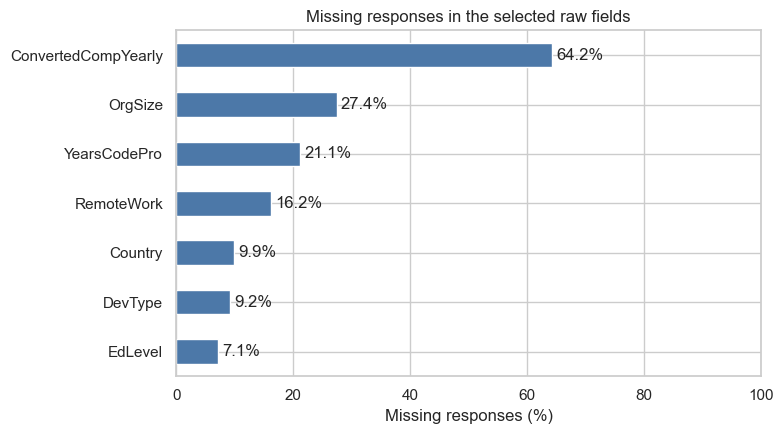

In [4]:
missing_percentages = (
    responses[assessment_columns].isna().mean().mul(100).sort_values()
)
fig, ax = plt.subplots(figsize=(8, 4.5))
missing_percentages.plot.barh(ax=ax, color="#4C78A8")
ax.set(
    title="Missing responses in the selected raw fields",
    xlabel="Missing responses (%)",
    ylabel="",
    xlim=(0, 100),
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
fig.tight_layout()
plt.show()

## 3. Data Preparation

### Clean: Define eligible compensation records and freeze the split

A usable outcome is numeric, finite, and greater than zero. Rows without one are excluded because their correct class is unknown. Eligible row indices are split before the median cutoff or labels exist. The cutoff then comes from training compensation only, and the same strict rule creates both labels.

In [5]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

eligible_mask = (
    numeric_compensation.notna()
    & np.isfinite(numeric_compensation)
    & numeric_compensation.gt(0)
)
eligible_indices = responses.index[eligible_mask]
train_indices, test_indices = train_test_split(
    eligible_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_compensation = numeric_compensation.loc[train_indices].copy()
test_compensation = numeric_compensation.loc[test_indices].copy()
compensation_cutoff_usd = float(train_compensation.median())

y_train = train_compensation.gt(compensation_cutoff_usd).astype("int8")
y_test = test_compensation.gt(compensation_cutoff_usd).astype("int8")
X_train = responses.loc[train_indices, FEATURE_COLUMNS].copy()
X_test = responses.loc[test_indices, FEATURE_COLUMNS].copy()

assert set(train_indices).isdisjoint(test_indices)
assert len(train_indices) + len(test_indices) == int(eligible_mask.sum())
assert np.isfinite(compensation_cutoff_usd) and compensation_cutoff_usd > 0
assert set(y_train.unique()) == {0, 1}
assert set(y_test.unique()) == {0, 1}
assert not y_train.isna().any() and not y_test.isna().any()
assert X_train.columns.tolist() == FEATURE_COLUMNS
assert X_test.columns.tolist() == FEATURE_COLUMNS
assert {TARGET_COLUMN, "CompTotal", "Currency"}.isdisjoint(
    X_train.columns
)
assert {TARGET_COLUMN, "CompTotal", "Currency"}.isdisjoint(
    X_test.columns
)

split_summary = pd.DataFrame(
    {
        "rows": [len(train_indices), len(test_indices)],
        "above_cutoff_share": [y_train.mean(), y_test.mean()],
    },
    index=["Training", "Held-out test"],
)
print(f"Raw responses: {len(responses):,}")
print(f"Eligible positive, finite compensation rows: {eligible_mask.sum():,}")
print(f"Global training cutoff: ${compensation_cutoff_usd:,.2f}")
display(split_summary.style.format({"above_cutoff_share": "{:.1%}"}))

Raw responses: 65,437
Eligible positive, finite compensation rows: 23,435
Global training cutoff: $65,000.00


,rows,above_cutoff_share
Training,18748,49.9%
Held-out test,4687,50.1%


### Analyze and visualize: training rows only

From this point until final evaluation, exploration uses training rows only. The held-out compensation distribution and predictor frequencies remain unopened.

,annual compensation (USD)
minimum,$1
25th percentile,"$32,370"
median,"$65,000"
75th percentile,"$108,000"
90th percentile,"$167,194"
99th percentile,"$400,000"
maximum,"$16,256,603"


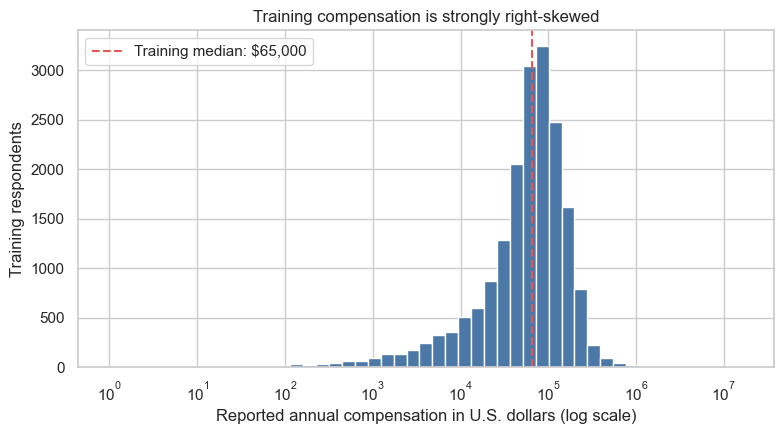

In [6]:
training_compensation_summary = train_compensation.quantile(
    [0, 0.25, 0.50, 0.75, 0.90, 0.99, 1]
).rename(
    index={
        0: "minimum",
        0.25: "25th percentile",
        0.50: "median",
        0.75: "75th percentile",
        0.90: "90th percentile",
        0.99: "99th percentile",
        1: "maximum",
    }
)
display(
    training_compensation_summary.to_frame("annual compensation (USD)")
    .style.format("${:,.0f}")
)

positive_minimum = train_compensation.min()
histogram_bins = np.geomspace(
    positive_minimum, train_compensation.max(), num=50
)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(train_compensation, bins=histogram_bins, color="#4C78A8")
ax.axvline(
    compensation_cutoff_usd,
    color="#E45756",
    linestyle="--",
    label=f"Training median: ${compensation_cutoff_usd:,.0f}",
)
ax.set_xscale("log")
ax.set(
    title="Training compensation is strongly right-skewed",
    xlabel="Reported annual compensation in U.S. dollars (log scale)",
    ylabel="Training respondents",
)
ax.legend()
fig.tight_layout()
plt.show()

In [7]:
for column in CATEGORICAL_COLUMNS:
    training_frequencies = (
        X_train[column]
        .fillna("Not reported")
        .value_counts(dropna=False)
        .head(10)
        .rename_axis(column)
        .to_frame("training rows")
    )
    print(f"Most common training values: {column}")
    display(training_frequencies)

Most common training values: Country


,training rows
Country,
United States of America,3801
Germany,1651
Ukraine,1184
United Kingdom of Great Britain and Northern Ireland,1086
India,821
France,733
Canada,680
Brazil,545
Poland,458


Most common training values: DevType


,training rows
DevType,
"Developer, full-stack",6651
"Developer, back-end",3805
"Developer, front-end",1136
"Developer, desktop or enterprise applications",846
"Developer, mobile",655
"Developer, embedded applications or devices",592
Other (please specify):,495
Data engineer,469
Engineering manager,435


Most common training values: EdLevel


,training rows
EdLevel,
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",8279
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5473
Some college/university study without earning a degree,2228
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",936
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",930
"Associate degree (A.A., A.S., etc.)",607
Something else,176
Primary/elementary school,119


Most common training values: OrgSize


,training rows
OrgSize,
20 to 99 employees,4019
100 to 499 employees,3654
"1,000 to 4,999 employees",2242
"10,000 or more employees",2218
2 to 9 employees,1781
10 to 19 employees,1653
500 to 999 employees,1328
"Just me - I am a freelancer, sole proprietor, etc.",803
"5,000 to 9,999 employees",769


Most common training values: RemoteWork


,training rows
RemoteWork,
"Hybrid (some remote, some in-person)",7946
Remote,7635
In-person,3159
Not reported,8


### Cleaning decisions

| Finding | Decision | Reason |
|---|---|---|
| Target is missing | Exclude the row from the eligible population | The correct class cannot be known and must not be invented. |
| Target is zero, negative, or non-finite | Treat it as unusable and report its count | Annual compensation for this question must be positive and finite. |
| Predictor is missing | Keep the row and handle missingness inside the training process | Dropping every incomplete row could remove a large, non-random group. |
| `YearsCodePro` contains special text | Convert the two documented boundary phrases to numeric values | The field represents a quantity even though its boundaries are written as text. |
| Compensation has very large valid values | Keep them | The median-based class depends on rank, so arbitrary trimming is unnecessary. |
| A categorical level has fewer than 100 training examples | Pool it during encoding | This limits unstable indicator columns while retaining common groups. |
| Some unused survey fields contain semicolon-separated answers | Leave those fields out | Expanding them would add work without helping the agreed six-field model. |

There is no blanket `dropna()` and no unexplained outlier deletion.

### Convert professional coding experience

The two documented boundary answers are converted once with a fixed rule. Any other text becomes missing and is handled later by the training-median filler. The function returns a new numeric series and does not change its input.

In [8]:
def convert_years_code_pro(series):
    """Convert professional-coding experience responses to numeric years.

    Parameters
    ----------
    series : pandas.Series
        Raw `YearsCodePro` survey responses.

    Returns
    -------
    pandas.Series
        A new float series where documented boundary phrases are numeric and
        unparseable responses are missing.
    """
    boundary_values = {
        "Less than 1 year": "0.5",
        "More than 50 years": "51",
    }
    normalized = series.astype("string").replace(boundary_values)
    return pd.to_numeric(normalized, errors="coerce").astype(float)


conversion_example = pd.Series(
    ["10", "Less than 1 year", "More than 50 years", "unknown", None]
)
conversion_example_before = conversion_example.copy(deep=True)
converted_example = convert_years_code_pro(conversion_example)
pd.testing.assert_series_equal(
    conversion_example, conversion_example_before, check_names=False
)
np.testing.assert_allclose(
    converted_example.iloc[:3], [10.0, 0.5, 51.0]
)
assert converted_example.iloc[3:].isna().all()

raw_training_years = X_train["YearsCodePro"]
cleaned_training_years = convert_years_code_pro(raw_training_years)
unexpected_training_years = (
    raw_training_years.notna() & cleaned_training_years.isna()
)
print(
    "Unexpected reported training values converted to missing: "
    f"{unexpected_training_years.sum():,}"
)
if unexpected_training_years.any():
    display(
        raw_training_years[unexpected_training_years]
        .value_counts()
        .to_frame("training rows")
    )

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
X_train_clean["YearsCodePro"] = cleaned_training_years
X_test_clean["YearsCodePro"] = convert_years_code_pro(
    X_test["YearsCodePro"]
)

Unexpected reported training values converted to missing: 0


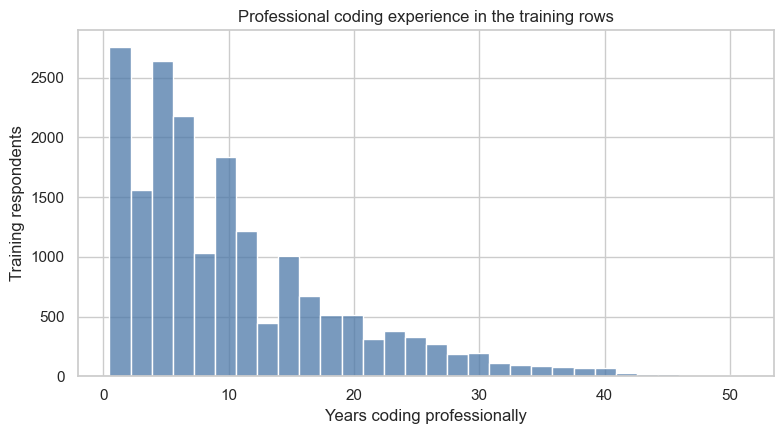

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(
    cleaned_training_years.dropna(),
    bins=30,
    color="#4C78A8",
    ax=ax,
)
ax.set(
    title="Professional coding experience in the training rows",
    xlabel="Years coding professionally",
    ylabel="Training respondents",
)
fig.tight_layout()
plt.show()

### One reusable preparation process

Numeric experience is filled with the training median and scaled. Each categorical field receives the explicit `Not reported` label when missing, is converted into yes/no columns, and pools levels seen fewer than 100 times in training. Unseen test or scenario categories are handled safely. All learned preparation stays inside one column transformer that will be fitted as part of the final model pipeline. Education and organization size remain categories because their response bands do not have equal numeric spacing.

In [10]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

MIN_CATEGORY_FREQUENCY = 100
NUMERIC_COLUMNS = ["YearsCodePro"]

numeric_preparation = Pipeline(
    steps=[
        ("fill_missing", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
)
categorical_preparation = Pipeline(
    steps=[
        (
            "fill_missing",
            SimpleImputer(strategy="constant", fill_value="Not reported"),
        ),
        (
            "encode",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=MIN_CATEGORY_FREQUENCY,
            ),
        ),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preparation, NUMERIC_COLUMNS),
        ("categorical", categorical_preparation, CATEGORICAL_COLUMNS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preparation_check = clone(preprocessor).fit(X_train_clean)
unseen_check = X_train_clean.iloc[[0]].copy()
unseen_check.loc[:, "YearsCodePro"] = np.nan
for column in CATEGORICAL_COLUMNS:
    unseen_check.loc[:, column] = f"Unseen {column} value"
transformed_check = preparation_check.transform(unseen_check)
assert transformed_check.shape[0] == 1
assert transformed_check.shape[1] > len(FEATURE_COLUMNS)
print("Training-fitted preparation accepted missing and unseen test values.")

Training-fitted preparation accepted missing and unseen test values.


### Predefine the country comparison

A country is supported only when it has at least 200 eligible training rows. Up to ten countries are chosen solely by training sample size, with alphabetical order breaking an exact count tie. Their local medians are calculated from training compensation and kept unrounded for later label comparisons. A missing country is excluded only from this descriptive comparison, not from the model. No held-out country result is used here.

In [11]:
from matplotlib.ticker import StrMethodFormatter

MIN_COUNTRY_TRAIN_ROWS = 200
MIN_COUNTRY_TEST_ROWS = 30
MAX_DISPLAY_COUNTRIES = 10

country_training_data = pd.DataFrame(
    {
        "Country": X_train_clean["Country"],
        "compensation_usd": train_compensation,
    }
)
missing_training_country_count = int(
    country_training_data["Country"].isna().sum()
)
country_training_summary = (
    country_training_data.dropna(subset=["Country"])
    .groupby("Country", as_index=False)
    .agg(
        training_count=("compensation_usd", "size"),
        training_median_usd=("compensation_usd", "median"),
    )
)
supported_country_summary = country_training_summary.loc[
    country_training_summary["training_count"] >= MIN_COUNTRY_TRAIN_ROWS
].copy()
supported_country_summary = supported_country_summary.sort_values(
    ["training_count", "Country"],
    ascending=[False, True],
).reset_index(drop=True)
top_country_summary = supported_country_summary.head(
    MAX_DISPLAY_COUNTRIES
).copy()
top_country_names = top_country_summary["Country"].tolist()

assert supported_country_summary["training_count"].ge(
    MIN_COUNTRY_TRAIN_ROWS
).all()
assert top_country_summary["training_count"].is_monotonic_decreasing
assert len(top_country_summary) <= MAX_DISPLAY_COUNTRIES

print(
    "Training rows excluded from the country comparison because country "
    f"was missing: {missing_training_country_count:,}"
)
display(
    top_country_summary.style.format(
        {
            "training_count": "{:,}",
            "training_median_usd": "${:,.0f}",
        }
    )
)

Training rows excluded from the country comparison because country was missing: 0


,Country,training_count,training_median_usd
0,United States of America,"3,801","$142,000"
1,Germany,"1,651","$73,036"
2,Ukraine,"1,184","$26,978"
3,United Kingdom of Great Britain and Northern Ireland,"1,086","$82,802"
4,India,821,"$17,945"
5,France,733,"$53,703"
6,Canada,680,"$87,231"
7,Brazil,545,"$24,243"
8,Poland,458,"$54,937"
9,Spain,450,"$48,333"


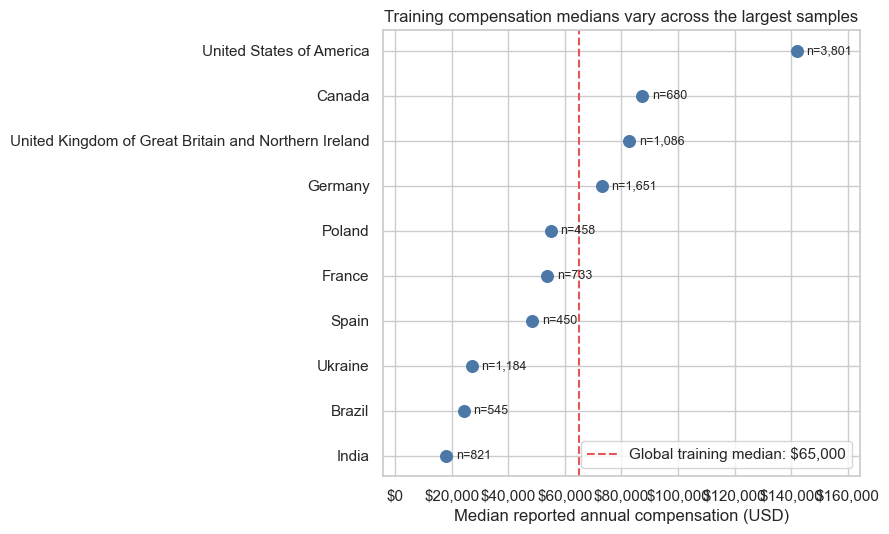

In [12]:
country_plot_data = top_country_summary.sort_values(
    "training_median_usd"
).reset_index(drop=True)
y_positions = np.arange(len(country_plot_data))
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(
    country_plot_data["training_median_usd"],
    y_positions,
    color="#4C78A8",
    s=70,
    zorder=3,
)
ax.axvline(
    compensation_cutoff_usd,
    color="#E45756",
    linestyle="--",
    label=f"Global training median: ${compensation_cutoff_usd:,.0f}",
)
for position, row in country_plot_data.iterrows():
    ax.annotate(
        f"n={int(row['training_count']):,}",
        (row["training_median_usd"], position),
        xytext=(7, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
    )
ax.set_yticks(y_positions, country_plot_data["Country"])
ax.set(
    title="Training compensation medians vary across the largest samples",
    xlabel="Median reported annual compensation (USD)",
    ylabel="",
)
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.legend(loc="lower right")
ax.margins(x=0.18)
fig.tight_layout()
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(
    IMAGE_DIR / "country_median_comparison.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

## 4. Modeling

### Baseline and logistic regression

The dummy baseline ignores respondent fields: its probabilities are the training class proportions and its class prediction is the majority class. The main model is one L2-regularized logistic regression inside the shared preparation pipeline. `max_iter=1000` gives the solver room to converge. There is no class weighting, resampling, parameter search, threshold adjustment, or second model. The default `0.50` probability threshold determines class predictions.

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

dummy_train_input = pd.DataFrame(
    {"constant": np.zeros(len(y_train))},
    index=y_train.index,
)
dummy_test_input = pd.DataFrame(
    {"constant": np.zeros(len(y_test))},
    index=y_test.index,
)
dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(dummy_train_input, y_train)

salary_model = Pipeline(
    steps=[
        ("prepare", clone(preprocessor)),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
salary_model.fit(X_train_clean, y_train)

model_iterations = salary_model.named_steps["model"].n_iter_
assert np.all(model_iterations < 1000)

logistic_test_probabilities = salary_model.predict_proba(
    X_test_clean
)[:, 1]
logistic_test_predictions = salary_model.predict(X_test_clean)
dummy_test_probabilities = dummy_model.predict_proba(
    dummy_test_input
)[:, 1]
dummy_test_predictions = dummy_model.predict(dummy_test_input)

assert np.isfinite(logistic_test_probabilities).all()
assert np.logical_and(
    logistic_test_probabilities >= 0, logistic_test_probabilities <= 1
).all()
assert set(np.unique(logistic_test_predictions)).issubset({0, 1})
assert np.array_equal(
    logistic_test_predictions, salary_model.predict(X_test_clean)
)
assert np.allclose(
    logistic_test_probabilities,
    salary_model.predict_proba(X_test_clean)[:, 1],
)
print(
    "Models fitted. Logistic solver iterations: "
    f"{model_iterations.tolist()}"
)

Models fitted. Logistic solver iterations: [39]


## 5. Evaluation and Answers

### Question 3: How accurately can the model identify unseen respondents above the global training cutoff?

This is the single final check on the untouched test rows. Every measure below uses the same labels, class predictions, and probabilities. Accuracy is the overall correct share; precision is the correct share among above-cutoff predictions; recall is the found share among truly above-cutoff rows; F1 balances precision and recall; and ROC-AUC measures probability ranking across possible thresholds.

In [14]:
from IPython.display import Markdown
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def evaluate_classifier(y_true, predictions, probabilities):
    """Return five classification measures for one held-out prediction set.

    Parameters
    ----------
    y_true : array-like
        Observed binary labels.
    predictions : array-like
        Predicted binary labels at the fixed 0.50 threshold.
    probabilities : array-like
        Predicted probabilities for class 1.

    Returns
    -------
    dict
        Accuracy, precision, recall, F1, and ROC-AUC values.
    """
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
    }


evaluation_table = pd.DataFrame.from_dict(
    {
        "Dummy baseline": evaluate_classifier(
            y_test,
            dummy_test_predictions,
            dummy_test_probabilities,
        ),
        "Logistic regression": evaluate_classifier(
            y_test,
            logistic_test_predictions,
            logistic_test_probabilities,
        ),
    },
    orient="index",
)
evaluation_table.index.name = "model"
display(evaluation_table.style.format("{:.3f}"))

accuracy_difference_points = 100 * (
    evaluation_table.loc["Logistic regression", "accuracy"]
    - evaluation_table.loc["Dummy baseline", "accuracy"]
)
roc_auc_difference = (
    evaluation_table.loc["Logistic regression", "roc_auc"]
    - evaluation_table.loc["Dummy baseline", "roc_auc"]
)
print(
    "Logistic minus baseline accuracy: "
    f"{accuracy_difference_points:+.1f} percentage points"
)
print(f"Logistic minus baseline ROC-AUC: {roc_auc_difference:+.3f}")

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Dummy baseline,0.499,0.000,0.000,0.000,0.500
Logistic regression,0.820,0.835,0.798,0.816,0.897


Logistic minus baseline accuracy: +32.1 percentage points
Logistic minus baseline ROC-AUC: +0.397


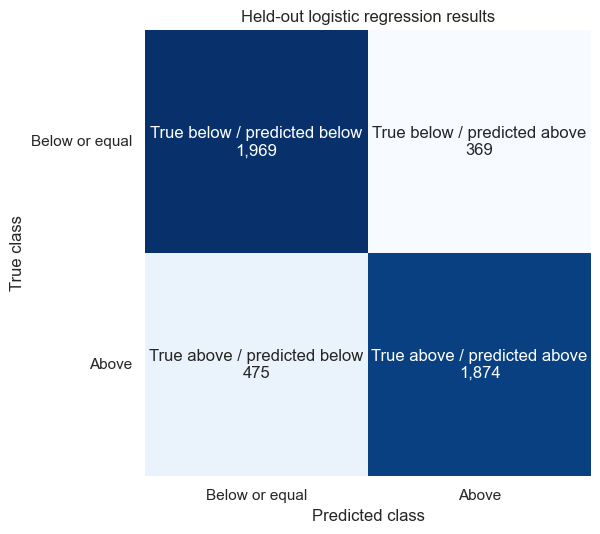

In [15]:
logistic_confusion_matrix = confusion_matrix(
    y_test, logistic_test_predictions, labels=[0, 1]
)
assert logistic_confusion_matrix.sum() == len(y_test)
confusion_labels = np.array(
    [
        [
            "True below / predicted below",
            "True below / predicted above",
        ],
        [
            "True above / predicted below",
            "True above / predicted above",
        ],
    ]
)
confusion_annotations = np.empty_like(confusion_labels, dtype=object)
for row in range(2):
    for column in range(2):
        confusion_annotations[row, column] = (
            f"{confusion_labels[row, column]}\n"
            f"{logistic_confusion_matrix[row, column]:,}"
        )

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(
    logistic_confusion_matrix,
    annot=confusion_annotations,
    fmt="",
    cmap="Blues",
    cbar=False,
    square=True,
    ax=ax,
)
ax.set(
    title="Held-out logistic regression results",
    xlabel="Predicted class",
    ylabel="True class",
)
ax.set_xticklabels(["Below or equal", "Above"])
ax.set_yticklabels(["Below or equal", "Above"], rotation=0)
fig.tight_layout()
fig.savefig(
    IMAGE_DIR / "confusion_matrix.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

In [16]:
baseline_accuracy = evaluation_table.loc[
    "Dummy baseline", "accuracy"
]
logistic_accuracy = evaluation_table.loc[
    "Logistic regression", "accuracy"
]
logistic_recall = evaluation_table.loc[
    "Logistic regression", "recall"
]
logistic_auc = evaluation_table.loc[
    "Logistic regression", "roc_auc"
]
false_positives = int(logistic_confusion_matrix[0, 1])
false_negatives = int(logistic_confusion_matrix[1, 0])
accuracy_result = (
    "exceeded" if logistic_accuracy > baseline_accuracy else "did not exceed"
)

display(
    Markdown(
        f"**Answer to Question 3.** On {len(y_test):,} held-out respondents "
        f"({y_test.mean():.1%} above the cutoff), logistic regression "
        f"reached {logistic_accuracy:.1%} accuracy and {logistic_auc:.3f} "
        f"ROC-AUC. Its accuracy {accuracy_result} the dummy baseline's "
        f"{baseline_accuracy:.1%} by {accuracy_difference_points:+.1f} "
        f"percentage points. Recall was {logistic_recall:.1%}. The model "
        f"placed {false_positives:,} below-cutoff respondents above the "
        f"cutoff and missed {false_negatives:,} truly above-cutoff "
        "respondents. These errors make the estimate unsuitable as a "
        "salary-setting or individual career decision rule."
    )
)

unexpected_test_years = (
    X_test["YearsCodePro"].notna()
    & X_test_clean["YearsCodePro"].isna()
)
print(
    "Unexpected held-out YearsCodePro values handled as missing: "
    f"{unexpected_test_years.sum():,}"
)

**Answer to Question 3.** On 4,687 held-out respondents (50.1% above the cutoff), logistic regression reached 82.0% accuracy and 0.897 ROC-AUC. Its accuracy exceeded the dummy baseline's 49.9% by +32.1 percentage points. Recall was 79.8%. The model placed 369 below-cutoff respondents above the cutoff and missed 475 truly above-cutoff respondents. These errors make the estimate unsuitable as a salary-setting or individual career decision rule.

Unexpected held-out YearsCodePro values handled as missing: 0


### Question 1: Which reported characteristics does the model rely on most?

Permutation importance measures how much held-out ROC-AUC falls when one original field is shuffled while the fitted model stays unchanged. Each field is shuffled ten times with seed 42. A larger mean decrease means the model relied more on that field; the variation across repeats shows sensitivity to the shuffle. This measures predictive reliance, not cause.

In [17]:
from sklearn.inspection import permutation_importance

FIELD_LABELS = {
    "Country": "Country of residence",
    "YearsCodePro": "Years coding professionally",
    "DevType": "Primary developer role",
    "EdLevel": "Highest completed education",
    "OrgSize": "Organization size",
    "RemoteWork": "Work arrangement",
}
permutation_result = permutation_importance(
    salary_model,
    X_test_clean,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
)
importance_table = pd.DataFrame(
    {
        "field": FEATURE_COLUMNS,
        "mean_auc_decrease": permutation_result.importances_mean,
        "shuffle_variation": permutation_result.importances_std,
    }
).sort_values("mean_auc_decrease", ascending=False)
importance_table["field_meaning"] = importance_table["field"].map(
    FIELD_LABELS
)
assert set(importance_table["field"]) == set(FEATURE_COLUMNS)
assert len(importance_table) == len(FEATURE_COLUMNS)
display(
    importance_table[
        ["field_meaning", "mean_auc_decrease", "shuffle_variation"]
    ].style.format(
        {
            "mean_auc_decrease": "{:.4f}",
            "shuffle_variation": "{:.4f}",
        }
    )
)

,field_meaning,mean_auc_decrease,shuffle_variation
0,Country of residence,0.2647,0.0094
1,Years coding professionally,0.0579,0.0026
2,Primary developer role,0.0163,0.0011
5,Work arrangement,0.0110,0.0008
4,Organization size,0.0088,0.0010
3,Highest completed education,0.0062,0.0012


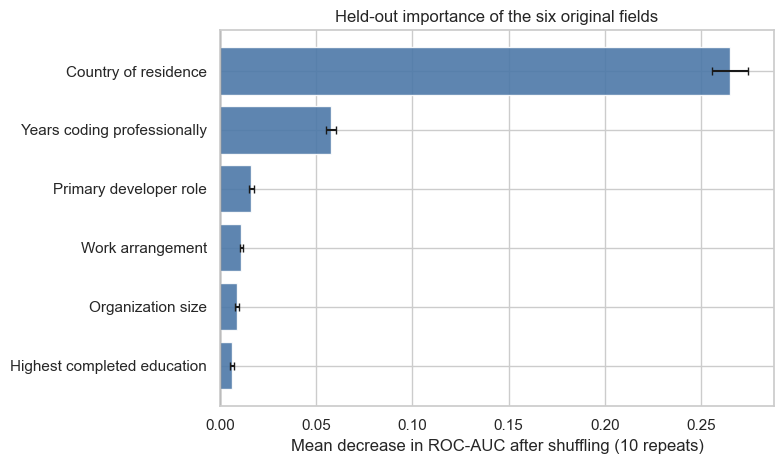

In [18]:
importance_plot_data = importance_table.sort_values(
    "mean_auc_decrease"
)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(
    importance_plot_data["field_meaning"],
    importance_plot_data["mean_auc_decrease"],
    xerr=importance_plot_data["shuffle_variation"],
    color="#4C78A8",
    alpha=0.9,
    capsize=3,
)
ax.axvline(0, color="#555555", linewidth=1)
ax.set(
    title="Held-out importance of the six original fields",
    xlabel="Mean decrease in ROC-AUC after shuffling (10 repeats)",
    ylabel="",
)
fig.tight_layout()
fig.savefig(
    IMAGE_DIR / "feature_importance.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

#### Meanings and model direction

The official survey question text below defines every field. Importance alone has no direction, so the next comparison changes one of the top two fields at a time while holding the other supplied values fixed. The reference categories are the most common jointly observed, fully reported training combination—not five independently combined modes.

In [19]:
importance_dictionary = (
    field_dictionary.merge(
        pd.Series(FIELD_LABELS, name="plain_language_name")
        .rename_axis("field")
        .reset_index(),
        on="field",
        how="left",
    )
    [["field", "plain_language_name", "question"]]
)
display(importance_dictionary)


def build_reference_profile(training_inputs):
    """Build one plausible reference row from cleaned training inputs.

    Parameters
    ----------
    training_inputs : pandas.DataFrame
        Cleaned, unencoded training fields in the approved order.

    Returns
    -------
    pandas.DataFrame
        One row using the most common fully reported categorical combination
        and the median reported professional experience.
    """
    complete_categories = training_inputs.dropna(
        subset=CATEGORICAL_COLUMNS
    )
    joint_counts = (
        complete_categories.groupby(CATEGORICAL_COLUMNS)
        .size()
        .sort_values(ascending=False)
    )
    if joint_counts.empty:
        raise ValueError(
            "No fully reported categorical combination exists in training."
        )
    common_combination = joint_counts.index[0]
    reference_values = dict(zip(CATEGORICAL_COLUMNS, common_combination))
    reference_values["YearsCodePro"] = float(
        training_inputs["YearsCodePro"].median()
    )
    return pd.DataFrame(
        [reference_values],
        columns=FEATURE_COLUMNS,
    )


reference_profile = build_reference_profile(X_train_clean)
assert reference_profile.columns.tolist() == FEATURE_COLUMNS
assert reference_profile[CATEGORICAL_COLUMNS].notna().all().all()
display(reference_profile)

,field,plain_language_name,question
0,Country,Country of residence,"Where do you live? <span style=""font-weight: b..."
1,YearsCodePro,Years coding professionally,"NOT including education, how many years have y..."
2,DevType,Primary developer role,Which of the following describes your current ...
3,EdLevel,Highest completed education,Which of the following best describes the high...
4,OrgSize,Organization size,Approximately how many people are employed by ...
5,RemoteWork,Work arrangement,Which best describes your current work situation?


,Country,YearsCodePro,DevType,EdLevel,OrgSize,RemoteWork
0,United States of America,8.0,"Developer, full-stack","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",100 to 499 employees,Remote


In [20]:
top_two_fields = importance_table.head(2)["field"].tolist()
direction_tables = []
for field in top_two_fields:
    if field == "YearsCodePro":
        observed_values = cleaned_training_years.dropna().to_numpy()
        quantile_targets = np.quantile(observed_values, [0.25, 0.50, 0.75])
        comparison_values = [
            float(observed_values[np.abs(observed_values - target).argmin()])
            for target in quantile_targets
        ]
        comparison_values = list(dict.fromkeys(comparison_values))
    else:
        supported_values = (
            X_train_clean[field]
            .dropna()
            .value_counts()
            .loc[lambda counts: counts >= MIN_COUNTRY_TRAIN_ROWS]
        )
        comparison_values = supported_values.head(5).index.tolist()

    comparison_profiles = pd.concat(
        [reference_profile.copy() for _ in comparison_values],
        ignore_index=True,
    )
    comparison_profiles[field] = comparison_values
    direction_table = pd.DataFrame(
        {
            "field": FIELD_LABELS[field],
            "supplied_value": comparison_values,
            "predicted_above_cutoff_probability": (
                salary_model.predict_proba(comparison_profiles)[:, 1]
            ),
        }
    )
    direction_tables.append(direction_table)

model_direction_table = pd.concat(direction_tables, ignore_index=True)
display(
    model_direction_table.style.format(
        {"predicted_above_cutoff_probability": "{:.1%}"}
    )
)

first_importance = importance_table.iloc[0]
second_importance = importance_table.iloc[1]
display(
    Markdown(
        f"**Answer to Question 1.** The model relied most on "
        f"**{first_importance['field_meaning']}**: shuffling it reduced "
        f"held-out ROC-AUC by {first_importance['mean_auc_decrease']:.4f} "
        f"on average. **{second_importance['field_meaning']}** ranked "
        f"second with a {second_importance['mean_auc_decrease']:.4f} mean "
        "decrease. The controlled probabilities above show direction while "
        "other supplied fields stay fixed. These are model associations, "
        "not evidence that changing a field causes compensation to change."
    )
)

,field,supplied_value,predicted_above_cutoff_probability
0,Country of residence,United States of America,94.7%
1,Country of residence,Germany,68.5%
2,Country of residence,Ukraine,13.0%
3,Country of residence,United Kingdom of Great Britain and Northern Ireland,63.8%
4,Country of residence,India,8.6%
5,Years coding professionally,4.000000,92.3%
6,Years coding professionally,8.000000,94.7%
7,Years coding professionally,14.000000,97.0%


**Answer to Question 1.** The model relied most on **Country of residence**: shuffling it reduced held-out ROC-AUC by 0.2647 on average. **Years coding professionally** ranked second with a 0.0579 mean decrease. The controlled probabilities above show direction while other supplied fields stay fixed. These are model associations, not evidence that changing a field causes compensation to change.

### Question 2: Does the global cutoff mean the same thing across countries?

The country rules and displayed countries were fixed from training rows before model evaluation. The comparison below now applies those exact, unrounded training medians to held-out compensation. A local label is `1` only when compensation is strictly greater than that country's training median.

In [21]:
supported_country_medians = supported_country_summary.set_index(
    "Country"
)["training_median_usd"]
country_test_comparison = pd.DataFrame(
    {
        "Country": X_test_clean["Country"],
        "compensation_usd": test_compensation,
        "global_label": y_test,
    }
)
country_test_comparison["local_training_median_usd"] = (
    country_test_comparison["Country"].map(supported_country_medians)
)
supported_country_test = country_test_comparison.dropna(
    subset=["local_training_median_usd"]
).copy()
supported_country_test["local_label"] = (
    supported_country_test["compensation_usd"]
    .gt(supported_country_test["local_training_median_usd"])
    .astype("int8")
)
supported_country_test["labels_disagree"] = (
    supported_country_test["local_label"]
    != supported_country_test["global_label"]
)

country_test_included = len(supported_country_test)
country_test_excluded = len(country_test_comparison) - country_test_included
missing_test_country_count = int(
    country_test_comparison["Country"].isna().sum()
)
overall_country_disagreement = supported_country_test[
    "labels_disagree"
].mean()

assert country_test_included + country_test_excluded == len(y_test)
assert supported_country_test["local_training_median_usd"].notna().all()
assert set(supported_country_test["local_label"].unique()).issubset({0, 1})

In [22]:
displayed_country_disagreement = (
    supported_country_test.loc[
        supported_country_test["Country"].isin(top_country_names)
    ]
    .groupby("Country")
    .agg(
        held_out_rows=("labels_disagree", "size"),
        disagreement_count=("labels_disagree", "sum"),
    )
    .reindex(top_country_names)
    .fillna(0)
)
count_columns = ["held_out_rows", "disagreement_count"]
displayed_country_disagreement[count_columns] = (
    displayed_country_disagreement[count_columns].astype(int)
)
displayed_country_disagreement["disagreement_percentage"] = (
    100
    * displayed_country_disagreement["disagreement_count"]
    / displayed_country_disagreement["held_out_rows"]
)
displayed_country_disagreement["reported_disagreement"] = [
    f"{percentage:.1f}%"
    if count >= MIN_COUNTRY_TEST_ROWS
    else "Too few held-out rows to report"
    for percentage, count in zip(
        displayed_country_disagreement["disagreement_percentage"],
        displayed_country_disagreement["held_out_rows"],
    )
]

display(
    displayed_country_disagreement[
        [
            "held_out_rows",
            "disagreement_count",
            "reported_disagreement",
        ]
    ]
)
display(
    Markdown(
        f"**Answer to Question 2.** Among {country_test_included:,} "
        f"held-out respondents in countries with at least "
        f"{MIN_COUNTRY_TRAIN_ROWS} training rows, "
        f"{overall_country_disagreement:.1%} changed above/below labels "
        "when the exact country training median replaced the global "
        f"training cutoff. {country_test_excluded:,} held-out rows were "
        f"excluded because their country was missing "
        f"({missing_test_country_count:,}) or unsupported. Neither label "
        "is universally correct: the global label compares converted U.S. "
        "dollars without local cost adjustment, while the country label "
        "compares only with sampled respondents in that country."
    )
)

,held_out_rows,disagreement_count,reported_disagreement
Country,,,
United States of America,876,358,40.9%
Germany,395,42,10.6%
Ukraine,290,93,32.1%
United Kingdom of Great Britain and Northern Ireland,305,54,17.7%
India,216,82,38.0%
France,185,29,15.7%
Canada,191,53,27.7%
Brazil,140,46,32.9%
Poland,128,18,14.1%


**Answer to Question 2.** Among 3,527 held-out respondents in countries with at least 200 training rows, 27.4% changed above/below labels when the exact country training median replaced the global training cutoff. 1,160 held-out rows were excluded because their country was missing (0) or unsupported. Neither label is universally correct: the global label compares converted U.S. dollars without local cost adjustment, while the country label compares only with sampled respondents in that country.

## 6. Deployment and Communication

### Question 4: What does the model predict for two fictional profiles that differ only in experience?

Both profiles reuse the jointly observed categorical reference combination from Question 1. Their experience values are the observed training responses nearest the cleaned training 25th and 75th percentiles. They are synthetic examples built from training summaries, not selected from held-out respondents or searched for a class change.

In [23]:
observed_experience = cleaned_training_years.dropna().to_numpy()
scenario_targets = np.quantile(observed_experience, [0.25, 0.75])
scenario_experience = [
    float(observed_experience[np.abs(observed_experience - target).argmin()])
    for target in scenario_targets
]
assert scenario_experience[0] < scenario_experience[1]

scenario_profiles = pd.concat(
    [reference_profile.copy(), reference_profile.copy()],
    ignore_index=True,
)
scenario_profiles.loc[:, "YearsCodePro"] = scenario_experience
scenario_profiles.index = ["Lower-experience profile", "Higher-experience profile"]

assert scenario_profiles.columns.tolist() == FEATURE_COLUMNS
assert scenario_profiles.loc[
    "Lower-experience profile", CATEGORICAL_COLUMNS
].equals(
    scenario_profiles.loc[
        "Higher-experience profile", CATEGORICAL_COLUMNS
    ]
)
assert scenario_profiles["YearsCodePro"].between(
    observed_experience.min(), observed_experience.max()
).all()
for column in CATEGORICAL_COLUMNS:
    assert scenario_profiles[column].isin(
        X_train_clean[column].dropna().unique()
    ).all()

scenario_probabilities = salary_model.predict_proba(scenario_profiles)[:, 1]
scenario_classes = (scenario_probabilities >= 0.50).astype("int8")
assert np.array_equal(
    scenario_classes, salary_model.predict(scenario_profiles)
)
assert np.logical_and(
    scenario_probabilities >= 0, scenario_probabilities <= 1
).all()
scenario_probability_difference = (
    scenario_probabilities[1] - scenario_probabilities[0]
)

scenario_results = scenario_profiles.copy()
scenario_results["predicted_above_cutoff_probability"] = (
    scenario_probabilities
)
scenario_results["predicted_class"] = np.where(
    scenario_classes == 1,
    "Above the global training cutoff",
    "At or below the global training cutoff",
)
display(
    scenario_results.style.format(
        {"predicted_above_cutoff_probability": "{:.1%}"}
    )
)
print(
    "Higher minus lower experience probability: "
    f"{scenario_probability_difference:+.1%}"
)

,Country,YearsCodePro,DevType,EdLevel,OrgSize,RemoteWork,predicted_above_cutoff_probability,predicted_class
Lower-experience profile,United States of America,4.000000,"Developer, full-stack","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",100 to 499 employees,Remote,92.3%,Above the global training cutoff
Higher-experience profile,United States of America,14.000000,"Developer, full-stack","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",100 to 499 employees,Remote,97.0%,Above the global training cutoff


Higher minus lower experience probability: +4.8%


In [24]:
lower_class = scenario_results.loc[
    "Lower-experience profile", "predicted_class"
]
higher_class = scenario_results.loc[
    "Higher-experience profile", "predicted_class"
]
display(
    Markdown(
        f"**Answer to Question 4.** With the same country, role, education, "
        f"organization size, and work arrangement, the model assigned the "
        f"{scenario_experience[0]:g}-year profile a "
        f"{scenario_probabilities[0]:.1%} probability ({lower_class}) and "
        f"the {scenario_experience[1]:g}-year profile a "
        f"{scenario_probabilities[1]:.1%} probability ({higher_class}). "
        f"The difference was {scenario_probability_difference:+.1%}. This "
        "is an illustration of a fitted one-year survey pattern, not a "
        "forecast of one person's future pay. Other factors are omitted, "
        "and gaining experience does not necessarily cause this change."
    )
)

**Answer to Question 4.** With the same country, role, education, organization size, and work arrangement, the model assigned the 4-year profile a 92.3% probability (Above the global training cutoff) and the 14-year profile a 97.0% probability (Above the global training cutoff). The difference was +4.8%. This is an illustration of a fitted one-year survey pattern, not a forecast of one person's future pay. Other factors are omitted, and gaining experience does not necessarily cause this change.

### Conclusions and responsible use

The final summary below is generated from the completed analysis so its numbers remain tied to the tables and figures above.

In [25]:
display(
    Markdown(
        f"#### 1. Which reported characteristics did the model rely on most?\n\n"
        f"{first_importance['field_meaning']} ranked first with a mean "
        f"held-out ROC-AUC decrease of "
        f"{first_importance['mean_auc_decrease']:.4f}; "
        f"{second_importance['field_meaning']} ranked second at "
        f"{second_importance['mean_auc_decrease']:.4f}. See "
        f"`images/feature_importance.png` and the controlled probability "
        f"table. These values describe model reliance, not cause.\n\n"
        f"#### 2. Did the global cutoff mean the same thing across countries?\n\n"
        f"No single comparison answers every purpose. Among "
        f"{country_test_included:,} supported-country test rows, "
        f"{overall_country_disagreement:.1%} received a different label "
        f"under the exact country training median; "
        f"{country_test_excluded:,} rows were excluded. See "
        f"`images/country_median_comparison.png`.\n\n"
        f"#### 3. How accurately did the model identify unseen respondents?\n\n"
        f"Logistic regression reached {logistic_accuracy:.1%} accuracy, "
        f"{logistic_recall:.1%} recall, and {logistic_auc:.3f} ROC-AUC on "
        f"{len(y_test):,} held-out rows. Baseline accuracy was "
        f"{baseline_accuracy:.1%}. See `images/confusion_matrix.png`.\n\n"
        f"#### 4. What happened in the fictional experience scenario?\n\n"
        f"Holding the five categorical fields fixed, the "
        f"{scenario_experience[0]:g}- and {scenario_experience[1]:g}-year "
        f"profiles received {scenario_probabilities[0]:.1%} and "
        f"{scenario_probabilities[1]:.1%} probabilities, a "
        f"{scenario_probability_difference:+.1%} difference. This is not "
        f"an individual pay forecast.\n\n"
        f"#### Main limits and next step\n\n"
        f"The voluntary sample, self-reported total compensation, missing "
        f"outcomes, converted U.S. dollars, omitted factors, and one-year "
        f"design limit generalization and prevent causal claims. A restrained "
        f"next step would repeat the same frozen analysis with "
        f"purchasing-power-adjusted compensation or a later survey year."
    )
)

#### 1. Which reported characteristics did the model rely on most?

Country of residence ranked first with a mean held-out ROC-AUC decrease of 0.2647; Years coding professionally ranked second at 0.0579. See `images/feature_importance.png` and the controlled probability table. These values describe model reliance, not cause.

#### 2. Did the global cutoff mean the same thing across countries?

No single comparison answers every purpose. Among 3,527 supported-country test rows, 27.4% received a different label under the exact country training median; 1,160 rows were excluded. See `images/country_median_comparison.png`.

#### 3. How accurately did the model identify unseen respondents?

Logistic regression reached 82.0% accuracy, 79.8% recall, and 0.897 ROC-AUC on 4,687 held-out rows. Baseline accuracy was 49.9%. See `images/confusion_matrix.png`.

#### 4. What happened in the fictional experience scenario?

Holding the five categorical fields fixed, the 4- and 14-year profiles received 92.3% and 97.0% probabilities, a +4.8% difference. This is not an individual pay forecast.

#### Main limits and next step

The voluntary sample, self-reported total compensation, missing outcomes, converted U.S. dollars, omitted factors, and one-year design limit generalization and prevent causal claims. A restrained next step would repeat the same frozen analysis with purchasing-power-adjusted compensation or a later survey year.